# Figure S3C: cell proportions

Run cells from top to bottom. Paths and thread counts are centralized in `config/`; embedded plots are retained as visual references from the source analysis.


In [ ]:
# Centralized paths and scheduler-aware thread limits.
repo_root <- if (file.exists("config/paths.R")) "." else if (file.exists("../config/paths.R")) ".." else stop("Run Jupyter from the repository root or notebooks/ directory.")
source(file.path(repo_root, "config", "paths.R"))


Loading required package: SeuratObject

Loading required package: sp

‘SeuratObject’ was built under R 4.4.1 but the current version is
4.4.2; it is recomended that you reinstall ‘SeuratObject’ as the ABI
for R may have changed


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


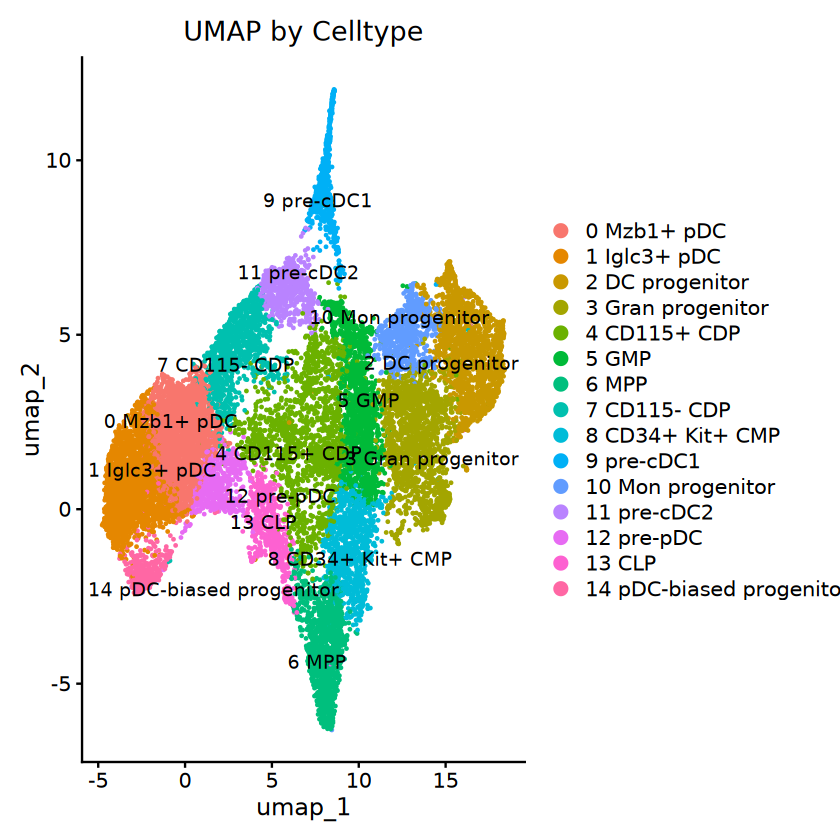

In [1]:
# 加载必要的库
library(Seurat)
library(ggplot2)

# 1. 读取数据
file_path <- p38_path("20250604p38-afterYZ/anno.rds")
sce <- readRDS(file_path)

# 2. 绘制 UMAP
# group.by 指定为 'celltype'，label = TRUE 会在簇上显示名称
p <- DimPlot(sce, reduction = "umap", group.by = "celltype", label = TRUE, repel = TRUE) +
     ggtitle("UMAP by Celltype") +
     theme(plot.title = element_text(hjust = 0.5))

# 3. 直接在 Jupyter 中打印显示
print(p)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Processing: 0 Mzb1+ pDC

Processing: 1 Iglc3+ pDC

Processing: 2 DC progenitor

Processing: 3 Gran progenitor

Processing: 4 CD115+ CDP

Processing: 5 GMP

Processing: 6 MPP

Processing: 7 CD115- CDP

Processing: 8 CD34+ Kit+ CMP

Processing: 9 pre-cDC1

Processing: 10 Mon progenitor

Processing: 11 pre-cDC2

Processing: 12 pre-pDC

Processing: 13 CLP

Processing: 14 pDC-biased progenitor



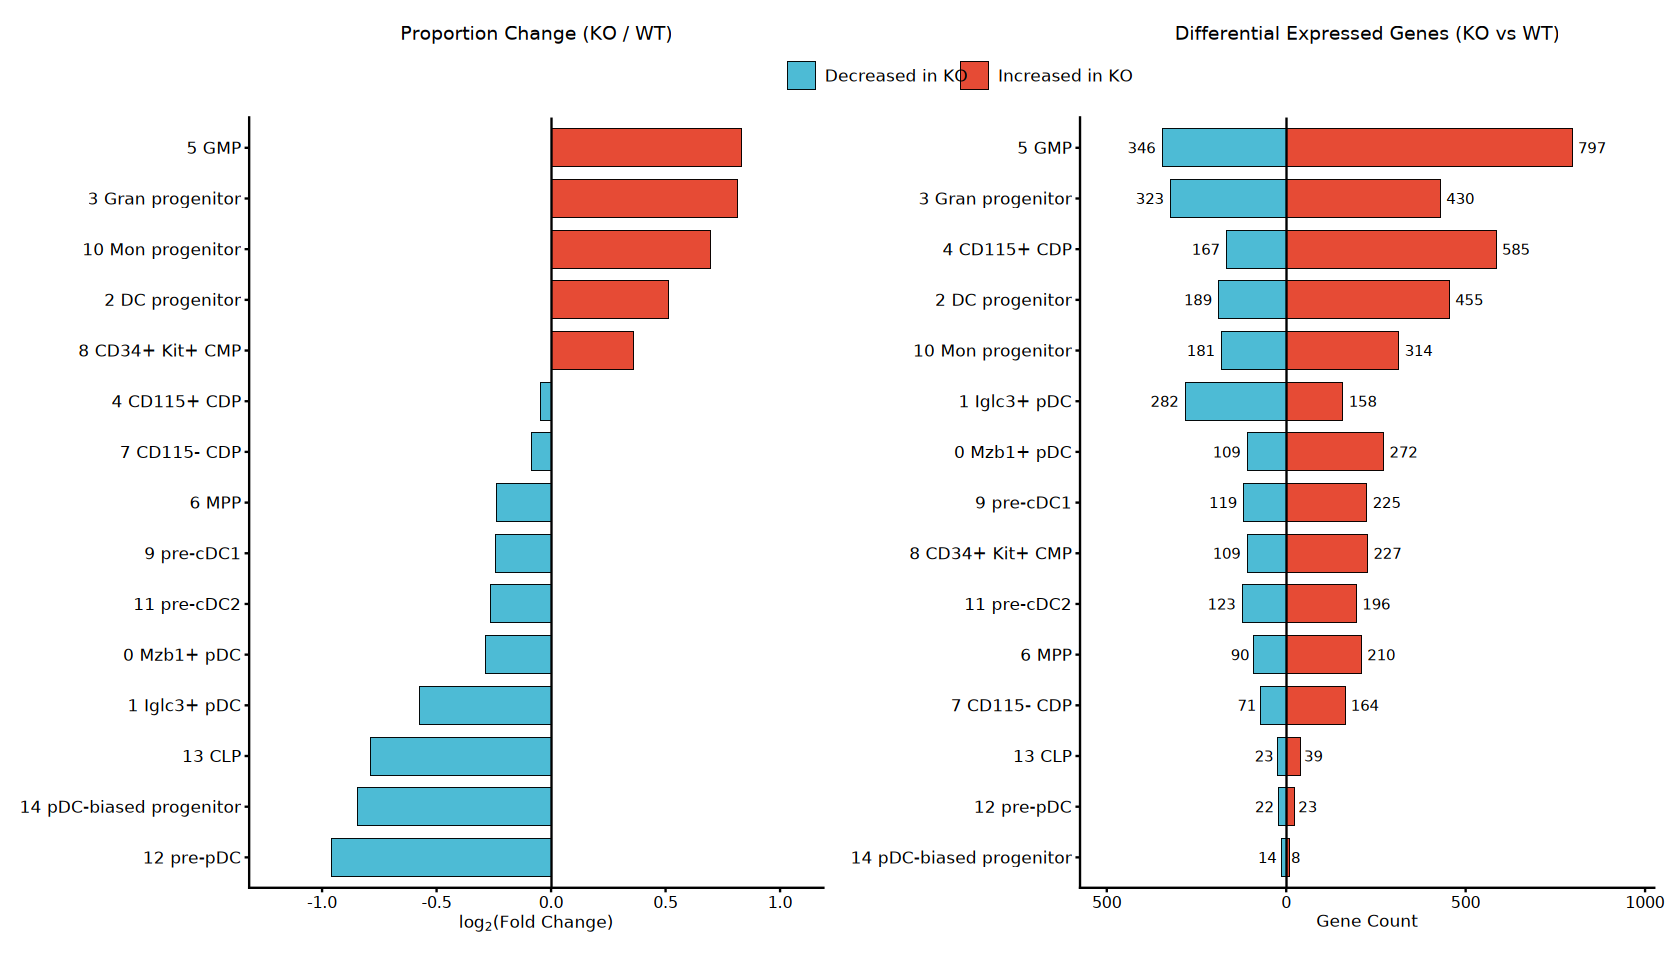

In [2]:
# 加载必要的库
library(Seurat)
library(ggplot2)
library(dplyr)
library(tidyr)
library(patchwork)

# --- 0. 环境准备 ---
seu <- sce  # 衔接上文的对象名
seu$celltype <- as.factor(seu$celltype)
cell_types <- levels(seu$celltype)

# --- 1. 差异表达分析 (DEG) ---
Idents(seu) <- "celltype"
deg_list <- list()

for (ct in cell_types) {
    message("Processing: ", ct)
    sub_seu <- subset(seu, idents = ct)
    
    # 直接检查 KO 和 WT 组是否满足细胞数要求
    if (sum(sub_seu$orig.ident == "KO") >= 3 && sum(sub_seu$orig.ident == "WT") >= 3) {
        markers <- FindMarkers(sub_seu, 
                               ident.1 = "KO", 
                               ident.2 = "WT", 
                               group.by = "orig.ident", 
                               logfc.threshold = 0.25, 
                               min.pct = 0.1, 
                               verbose = FALSE)
        
        # 统计显著差异基因 (p_val_adj < 0.05)
        sig_markers <- markers %>% filter(p_val_adj < 0.05)
        
        deg_list[[ct]] <- data.frame(
            Cluster = ct,
            Up = sum(sig_markers$avg_log2FC > 0),
            Down = sum(sig_markers$avg_log2FC < 0)
        )
    } else {
        deg_list[[ct]] <- data.frame(Cluster = ct, Up = 0, Down = 0)
    }
}
deg_df <- do.call(rbind, deg_list)

# --- 2. 比例数据处理 (Proportion) ---
prop_df <- as.data.frame(table(seu$celltype, seu$orig.ident))
colnames(prop_df) <- c("celltype", "Condition", "Count")

comparison_df <- prop_df %>%
  group_by(Condition) %>%
  mutate(Percentage = (Count / sum(Count)) * 100) %>%
  ungroup() %>%
  # 筛选 KO 和 WT
  filter(Condition %in% c("KO", "WT")) %>%
  select(celltype, Condition, Percentage) %>%
  pivot_wider(names_from = Condition, values_from = Percentage) %>%
  # 计算 Log2FC: KO / WT
  mutate(Log2FC = log2((KO + 0.01) / (WT + 0.01))) %>%
  mutate(Direction = ifelse(Log2FC > 0, "Increased in KO", "Decreased in KO"))

# --- 3. 统一的主题风格定义 ---
optimized_theme <- theme_classic() +
  theme(
    text = element_text(family = "sans"),
    plot.title = element_text(size = 11, face = "bold", hjust = 0.5),
    axis.title = element_text(size = 10, face = "bold"),
    axis.text.y = element_text(size = 10, face = "plain", color = "black"),
    axis.text.x = element_text(size = 9, face = "plain", color = "black"),
    legend.position = "top",
    legend.title = element_blank(),
    legend.text = element_text(size = 10),
    plot.margin = margin(t = 10, r = 10, b = 10, l = 10)
  )

# --- 4. 绘图 A：DEGs (KO vs WT) ---
plot_deg_sorted <- deg_df %>%
  mutate(Total = Up + Down) %>%
  arrange(Total) %>% 
  mutate(Cluster = factor(Cluster, levels = Cluster)) %>% 
  mutate(Down_Neg = -Down) %>%
  tidyr::pivot_longer(cols = c("Up", "Down_Neg"), names_to = "Direction", values_to = "Count") %>%
  mutate(Direction = ifelse(Direction == "Up", "Increased in KO", "Decreased in KO"))

p1_opt <- ggplot(plot_deg_sorted, aes(x = Cluster, y = Count, fill = Direction)) +
  geom_bar(stat = "identity", width = 0.75, color = "black", linewidth = 0.2) +
  # 柱子上的数字标注
  geom_text(data = filter(plot_deg_sorted, Direction == "Increased in KO"),
            aes(label = Count), hjust = -0.2, size = 3) +
  geom_text(data = filter(plot_deg_sorted, Direction == "Decreased in KO"),
            aes(label = abs(Count)), hjust = 1.2, size = 3) +
  scale_fill_manual(values = c("Increased in KO" = "#E64B35", "Decreased in KO" = "#4DBBD5")) +
  scale_y_continuous(labels = function(x) abs(x), expand = expansion(mult = c(0.2, 0.2))) +
  coord_flip() +
  optimized_theme +
  labs(title = "Differential Expressed Genes (KO vs WT)", x = "", y = "Gene Count") +
  geom_hline(yintercept = 0, linewidth = 0.5)

# --- 5. 绘图 B：Proportion (KO vs WT, 移除数值标注) ---
plot_prop_sorted <- comparison_df %>%
  arrange(Log2FC) %>% 
  mutate(celltype = factor(celltype, levels = celltype))

p2_opt <- ggplot(plot_prop_sorted, aes(x = celltype, y = Log2FC, fill = Direction)) +
  geom_bar(stat = "identity", width = 0.75, color = "black", linewidth = 0.2) +
  # 不再添加 geom_text
  scale_fill_manual(values = c("Increased in KO" = "#E64B35", "Decreased in KO" = "#4DBBD5")) +
  scale_y_continuous(expand = expansion(mult = c(0.2, 0.2))) +
  coord_flip() +
  optimized_theme +
  labs(title = "Proportion Change (KO / WT)", x = "", y = expression(log[2]*"(Fold Change)")) +
  geom_hline(yintercept = 0, linewidth = 0.5)

# --- 6. 合并展示 ---
options(repr.plot.width = 14, repr.plot.height = 8)
combined_plot <- p2_opt + p1_opt + 
  plot_layout(guides = "collect") & 
  theme(legend.position = "top")

print(combined_plot)

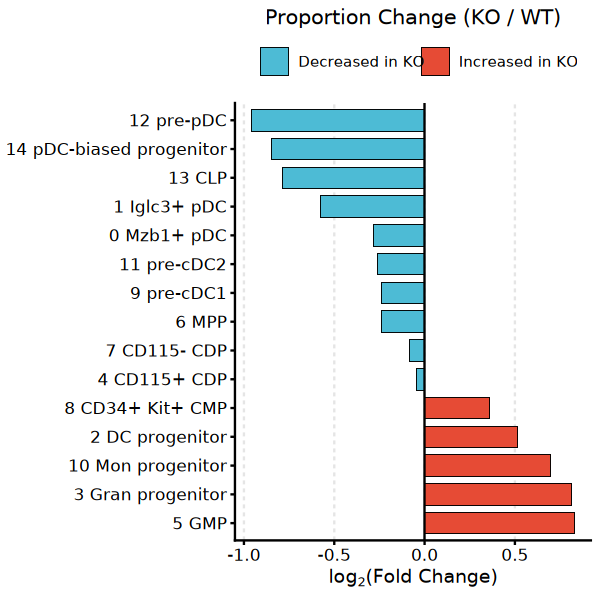

In [4]:
library(dplyr)
library(tidyr)
library(ggplot2)

# --- 1. 准备比例数据 (如果你在上一个单元格已经生成 comparison_df，这步可跳过) ---
# 确保数据是最新的
prop_df <- as.data.frame(table(seu$celltype, seu$orig.ident))
colnames(prop_df) <- c("celltype", "Condition", "Count")

comparison_df <- prop_df %>%
  group_by(Condition) %>%
  mutate(Percentage = (Count / sum(Count)) * 100) %>%
  ungroup() %>%
  filter(Condition %in% c("KO", "WT")) %>%
  select(celltype, Condition, Percentage) %>%
  pivot_wider(names_from = Condition, values_from = Percentage) %>%
  # 添加微小值避免除以0
  mutate(Log2FC = log2((KO + 0.01) / (WT + 0.01))) %>%
  mutate(Direction = ifelse(Log2FC > 0, "Increased in KO", "Decreased in KO"))

# --- 2. 关键修改：排序逻辑 ---
# 目标：降低的(负值)在上面，升高的(正值)在下面
# 逻辑：在 coord_flip 中，因子水平的顺序是从下往上画的。
# 所以我们需要将 正值(Increased) 设为前面的因子水平(下)，负值(Decreased) 设为后面的因子水平(上)。
# 方法：按照 Log2FC 降序排列 (desc)
plot_prop_sorted <- comparison_df %>%
  arrange(desc(Log2FC)) %>%  # 降序：正数在前，负数在后
  mutate(celltype = factor(celltype, levels = celltype))

# --- 3. 绘图 ---
p_prop_only <- ggplot(plot_prop_sorted, aes(x = celltype, y = Log2FC, fill = Direction)) +
  geom_bar(stat = "identity", width = 0.75, color = "black", linewidth = 0.2) +
  
  # 颜色设置
  scale_fill_manual(values = c("Increased in KO" = "#E64B35", "Decreased in KO" = "#4DBBD5")) +
  
  # 坐标轴翻转
  coord_flip() +
  
  # 主题设置
  theme_classic() +
  theme(
    text = element_text(family = "sans"),
    plot.title = element_text(size = 12, face = "bold", hjust = 0.5),
    axis.title = element_text(size = 11, face = "bold"),
    axis.text.y = element_text(size = 10, color = "black"), # 细胞类型标签
    axis.text.x = element_text(size = 10, color = "black"),
    legend.position = "top", # 图例放上面
    legend.title = element_blank(),
    panel.grid.major.x = element_line(color = "grey90", linetype = "dashed") # 增加竖向网格辅助看数值
  ) +
  
  # 标签和参考线
  labs(title = "Proportion Change (KO / WT)", x = "", y = expression(log[2]*"(Fold Change)")) +
  geom_hline(yintercept = 0, linewidth = 0.5)

options(repr.plot.width = 5, repr.plot.height = 5)
print(p_prop_only)

In [5]:
# --- 1. 针对 AI 优化的主题调整 ---
# 在原有图表基础上，强制去除背景色，确保它是完全透明的
p_export <- p_prop_only + 
  theme(
    # 去除绘图区背景
    plot.background = element_rect(fill = "transparent", color = NA),
    # 去除面板背景
    panel.background = element_rect(fill = "transparent", color = NA)
  )

# --- 2. 导出 PDF ---
ggsave(
  filename = p38_path("20260123p38组图/Proportion_Change_KO_vs_WT.pdf"), 
  plot = p_export,
  width = 5, 
  height = 5, 
  units = "in",
  
  # 关键参数设置
  device = "pdf",       # 使用标准 PDF 设备
  useDingbats = FALSE,  # 确保符号兼容 AI
  bg = "transparent"    # 告诉 ggsave 不要加白色底色
)

message("PDF保存成功：Proportion_Change_KO_vs_WT.pdf")

PDF保存成功：Proportion_Change_KO_vs_WT.pdf

